In [3]:
!pip install --upgrade pandas-profiling
!pip install shap
!pip install sklearn-pandas==1.5.0

  Using cached joblib-1.1.1-py2.py3-none-any.whl.metadata (5.2 kB)
Using cached joblib-1.1.1-py2.py3-none-any.whl (309 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
econml 0.15.1 requires scikit-learn<1.6,>=1.0, but you have scikit-learn 1.6.1 which is incompatible.
responsibleai 0.36.0 requires pandas<2.0.0,>=0.25.1, but you have pandas 2.2.3 which is incompatible.
responsibleai 0.36.0 requires scikit-learn!=1.1,<=1.5.1,>=0.22.1, but you have scikit-learn 1.6.1 which is incompatible.
scikit-learn 1.6.1 requires joblib>=1.2.0, but you have joblib 1.1.1 which is incompatible.
ydata-profiling 4.14.0 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\TaeyoonKim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
econml 0.15.1 requires scikit-learn<1.6,>=1.0, but you have scikit-learn 1.6.1 which is incompatible.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.1 which is incompatible.
responsibleai 0.36.0 requires pandas<2.0.0,>=0.25.1, but you have pandas 2.2.3 which is incompatible.
responsibleai 0.36.0 requires scikit-learn!=1.1,<=1.5.1,>=0.22.1, but you have scikit-learn 1.6.1 which is incompatible.
ydata-profiling 4.14.0 requires visions[type_image_path]<0.8.2,>=0.7.5, but you have visions 0.7.4 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\TaeyoonKim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\TaeyoonKim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
# library for feature engineering and EDA
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image
import pandas_profiling
from datetime import datetime
import random

# library for statistic
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
from scipy.stats import boxcox, norm
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import uniform as sp_randFloat
from scipy.stats import randint as sp_randInt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.formula.api import ols
import sklearn_pandas
from sklearn_pandas import DataFrameMapper, CategoricalImputer

# library for sampling 
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SVMSMOTE

# library for machine learning
import sklearn
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import shap
%matplotlib inline

In [28]:
df = pd.read_csv("data/application_record.csv")
df_record = pd.read_csv("data/data.csv")

In [29]:
df_record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [30]:
df_record.sort_values(["ID", "MONTHS_BALANCE"], ascending=False).groupby("ID").first()

,MONTHS_BALANCE,STATUS
ID,,
5001711,0,X
5001712,0,C
5001713,0,X
5001714,0,X
5001715,0,X
...,...,...
5150482,-11,C
5150483,0,X
5150484,0,C


In [31]:
print("Duplicated :", len(df[df.duplicated()])) 
print("Duplicated :", len(df_record[df_record.duplicated()])) 

Duplicated : 0
Duplicated : 0


In [32]:
len(df)

438557

In [34]:
df.merge(df_record, on="ID", how="inner").head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [35]:
len(df.merge(df_record, on="ID", how="inner"))

777715

In [36]:
print(len(df_record))
print(df_record.ID.nunique())

1048575
45985


In [37]:
df_record.MONTHS_BALANCE.unique()

array([  0,  -1,  -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10, -11, -12,
       -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25,
       -26, -27, -28, -29, -30, -31, -32, -33, -34, -35, -36, -37, -38,
       -39, -40, -41, -42, -43, -44, -45, -46, -47, -48, -49, -50, -51,
       -52, -53, -54, -55, -56, -57, -58, -59, -60], dtype=int64)

In [38]:
df_record_filtered = df_record.sort_values(["ID", "MONTHS_BALANCE"], ascending=False).groupby("ID").first()
df_record_filtered

,MONTHS_BALANCE,STATUS
ID,,
5001711,0,X
5001712,0,C
5001713,0,X
5001714,0,X
5001715,0,X
...,...,...
5150482,-11,C
5150483,0,X
5150484,0,C


In [39]:
df = df.merge(df_record_filtered, on="ID", how="inner")

In [41]:
df.STATUS.unique()

array(['C', '0', 'X', '1', '5', '3', '4', '2'], dtype=object)

In [42]:
condition_no_approval = df.STATUS.isin(["0","1","2","3","4","5"])
df["Target_Status"] = None
df.loc[condition_no_approval,"Target_Status"] = 0
df.loc[~condition_no_approval, "Target_Status"] = 1

In [43]:
df.head(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,Target_Status
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,0,C,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,0,C,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,0,C,1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,-22,X,1


In [44]:
# 기존 STATUS 제거
df = df.drop("STATUS", axis=1)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null 

In [46]:
df.isna().sum().sort_values(ascending=False)

OCCUPATION_TYPE        11323
ID                         0
CODE_GENDER                0
MONTHS_BALANCE             0
CNT_FAM_MEMBERS            0
FLAG_EMAIL                 0
FLAG_PHONE                 0
FLAG_WORK_PHONE            0
FLAG_MOBIL                 0
DAYS_EMPLOYED              0
DAYS_BIRTH                 0
NAME_HOUSING_TYPE          0
NAME_FAMILY_STATUS         0
NAME_EDUCATION_TYPE        0
NAME_INCOME_TYPE           0
AMT_INCOME_TOTAL           0
CNT_CHILDREN               0
FLAG_OWN_REALTY            0
FLAG_OWN_CAR               0
Target_Status              0
dtype: int64

In [48]:
# categorical and numeric columns
for column_name in list(df.columns):
    print(column_name, df[column_name].dtype, df[column_name].unique())
    
list_cast_object = ["ID", "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"]
for column_name in list_cast_object:
  df[column_name] = df[column_name].astype(object)

ID object [5008804 5008805 5008806 ... 5149838 5150049 5150337]
CODE_GENDER object ['M' 'F']
FLAG_OWN_CAR object ['Y' 'N']
FLAG_OWN_REALTY object ['Y' 'N']
CNT_CHILDREN int64 [ 0  1  3  2  4  5 14 19  7]
AMT_INCOME_TOTAL float64 [ 427500.   112500.   270000.   283500.   135000.   130500.   157500.
  405000.   211500.   360000.   126000.   315000.   247500.   297000.
  225000.   166500.   216000.   255150.   148500.   202500.    94500.
  450000.   180000.    90000.   765000.   382500.   144000.   229500.
  292500.    74250.    40500.   337500.   193500.   267750.   139500.
   67500.   252000.   900000.   115290.   279000.    76500.   234000.
   81000.   108000.    99000.   198000.    45000.   238500.   117000.
  153000.  1350000.   445500.   495000.    85500.   306000.   562500.
  189000.   328500.   310500.   540000.   171000.   675000.   121500.
   72000.    65250.   184500.   103500.   162000.   165150.    54000.
  243000.   256500.    33300.   697500.   101250.    58500.   110250.
 

In [49]:
list_categorical_columns = list(df.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df.select_dtypes(include=['float64','int64']).columns)
target_column = "Target_Status"
print(len(df))
print(len(df.columns))
print(len(list_categorical_columns))
print(len(list_numeric_columns))

36457
20
14
6


In [ ]:
list_categorical_columns.remove(target_column)

In [ ]:
df[target_column].describe()

count     36457
unique        2
top           1
freq      27619
Name: Target_Status, dtype: int64

<Axes: xlabel='Target_Status', ylabel='count'>

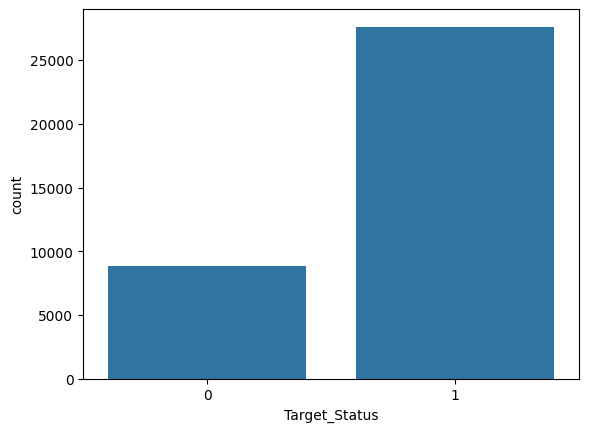

In [ ]:
sns.countplot(x=target_column, data=df)

In [ ]:
df[list_categorical_columns].nunique().sort_values() 


FLAG_MOBIL                 1
CODE_GENDER                2
FLAG_OWN_CAR               2
FLAG_OWN_REALTY            2
FLAG_WORK_PHONE            2
FLAG_PHONE                 2
FLAG_EMAIL                 2
NAME_INCOME_TYPE           5
NAME_EDUCATION_TYPE        5
NAME_FAMILY_STATUS         5
NAME_HOUSING_TYPE          6
OCCUPATION_TYPE           18
ID                     36457
dtype: int64

In [ ]:
df = df.drop(["ID", "FLAG_MOBIL"], axis=1)

In [55]:
list_categorical_columns.remove("ID")
list_categorical_columns.remove("FLAG_MOBIL")

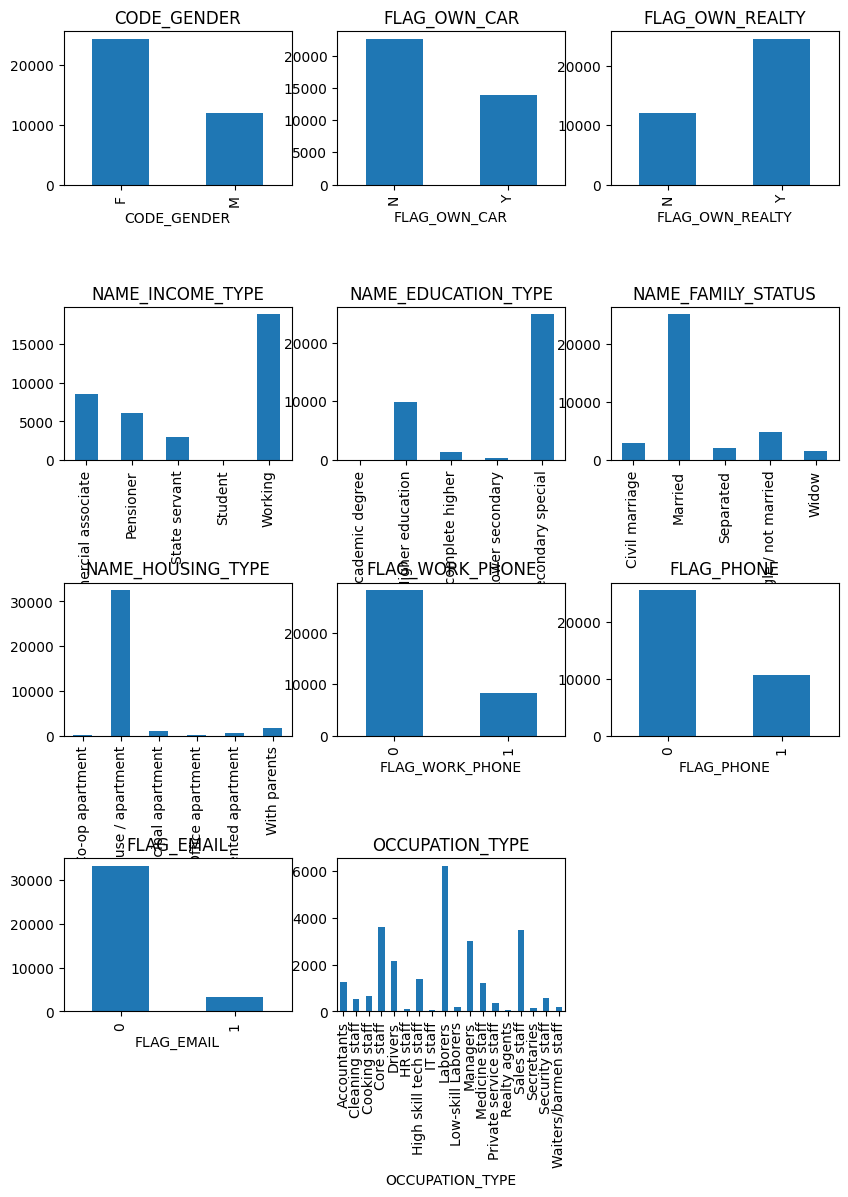

In [60]:
plt.figure(figsize=(10,10))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.8, wspace=0.2)
for column_name in list_categorical_columns:
    plt.subplot(4,3,x)
    x = x+1
    df[column_name].value_counts().sort_index().plot(kind='bar')
    plt.title(column_name)
plt.show()

<Axes: xlabel='CODE_GENDER'>

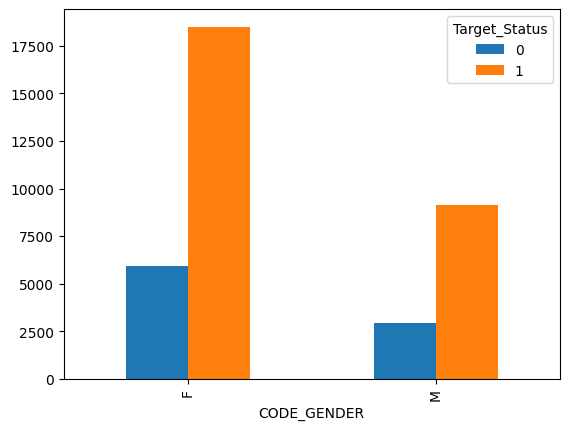

In [61]:
df_poutcome_dependent = pd.crosstab(df[list_categorical_columns[0]],df[target_column])
df_poutcome_dependent.plot(kind='bar')

In [62]:
pd.crosstab(df[list_categorical_columns[0]], df[target_column] , normalize="index")

Target_Status,0,1
CODE_GENDER,,
F,0.242448,0.757552
M,0.242371,0.757629


<Axes: xlabel='CODE_GENDER'>

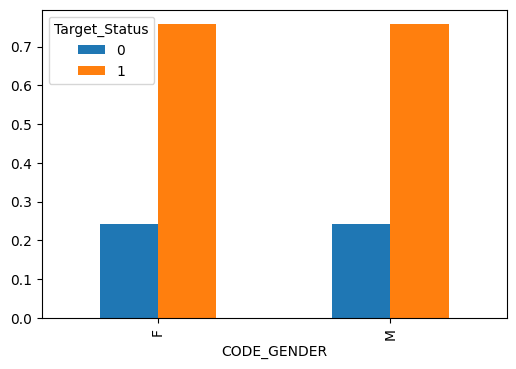

In [64]:
df_poutcome_dependent_ratio = pd.crosstab(df[list_categorical_columns[0]], df[target_column] , normalize="index")
df_poutcome_dependent_ratio.plot.bar(figsize=(6,4))

<Figure size 3000x3000 with 0 Axes>

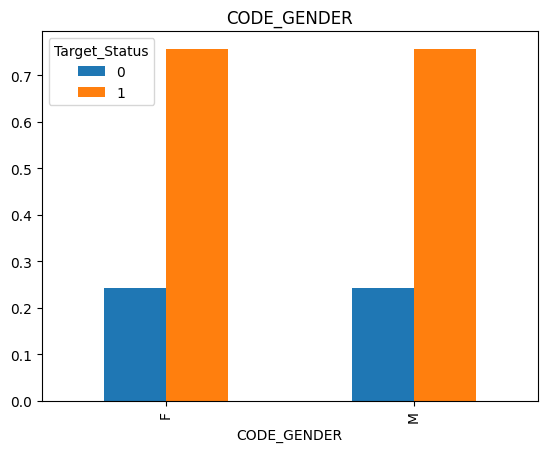

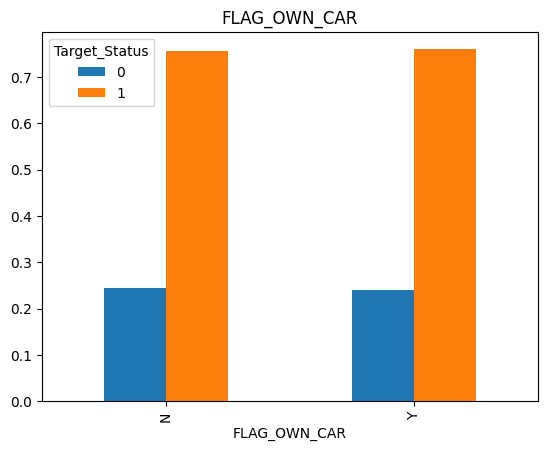

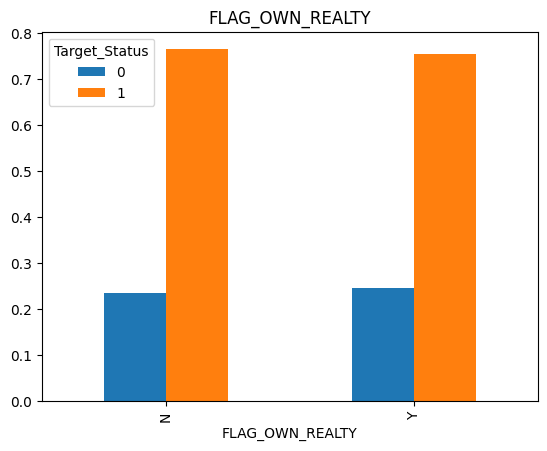

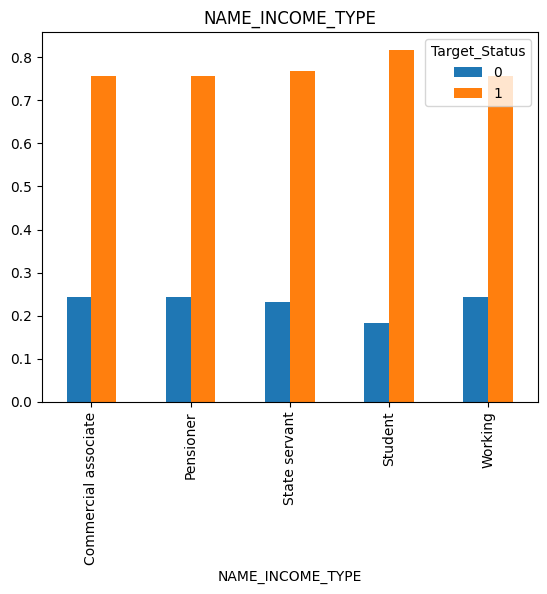

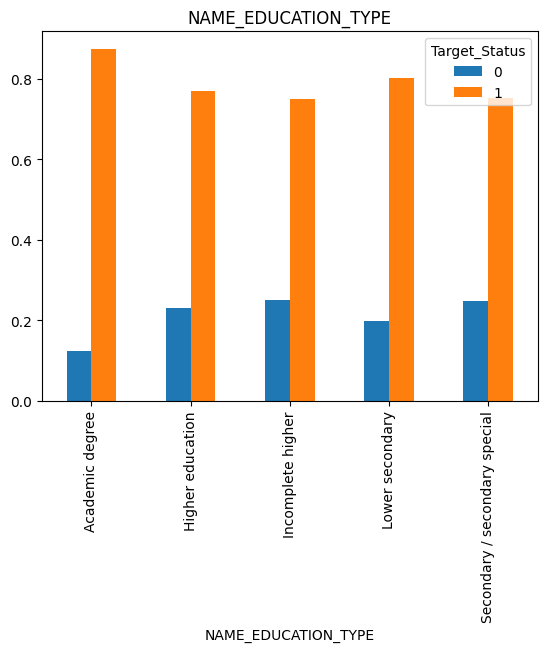

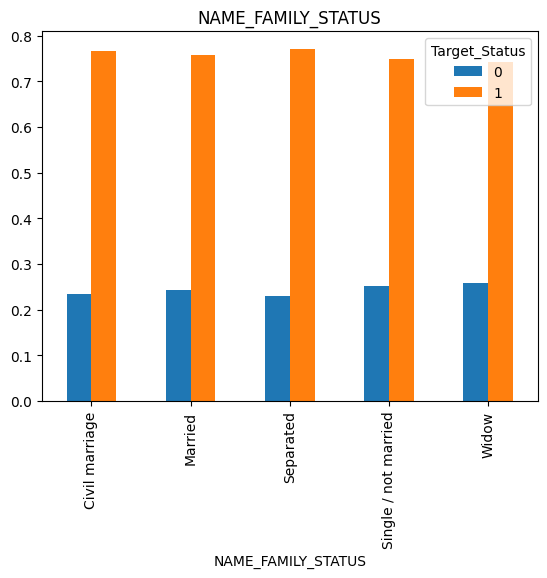

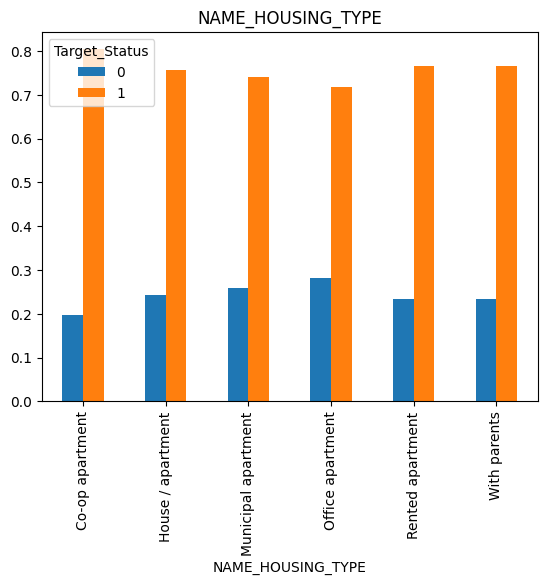

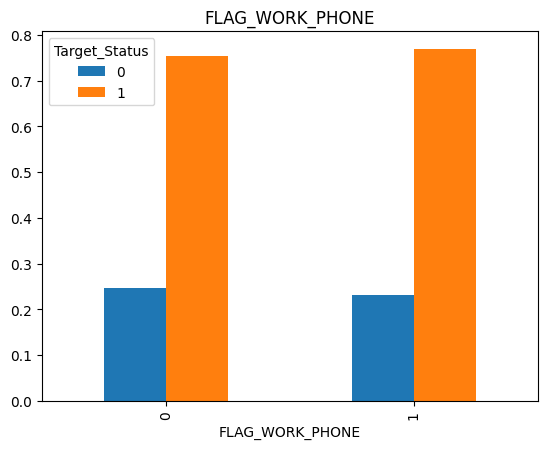

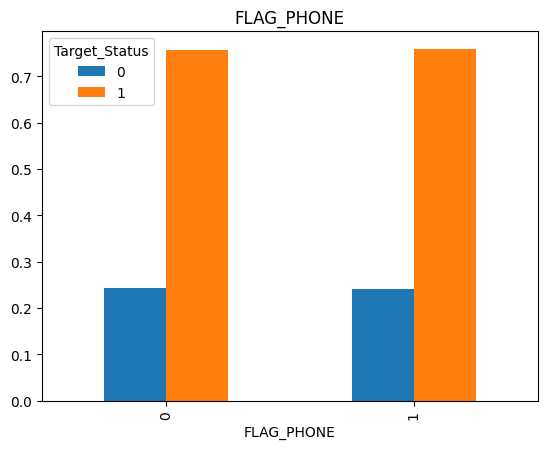

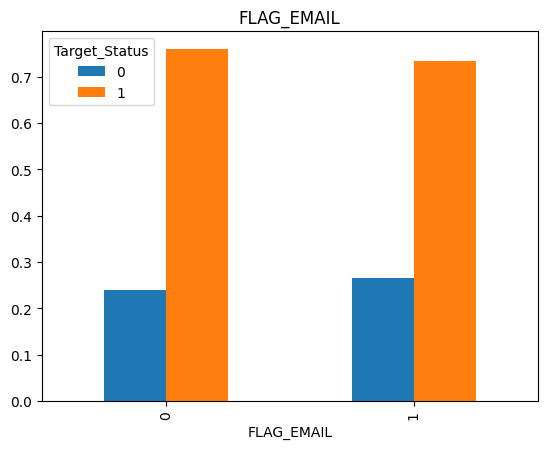

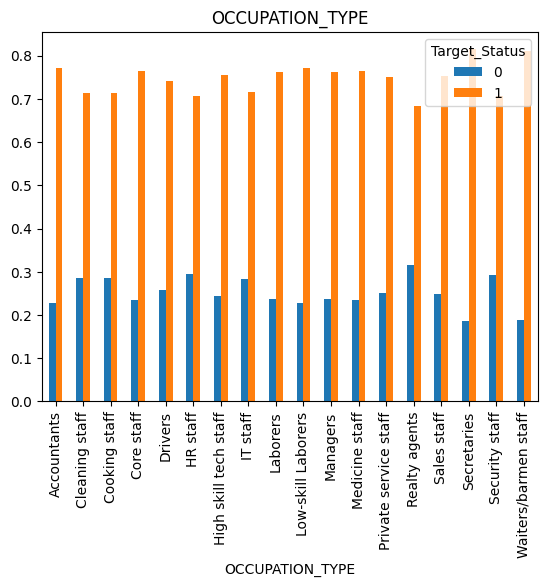

In [65]:
plt.figure(figsize=(30,30))
#plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.8, wspace=0.2)
for column_name in list_categorical_columns:
    pd.crosstab(df[column_name], df[target_column], normalize="index").plot.bar()
    plt.title(column_name)
plt.show()

In [66]:
list_meaningful_column_by_chi = []
for column_name in list_categorical_columns:
  statistic, pvalue, _, _ = chi2_contingency(pd.crosstab(df[target_column], df[column_name]))
  if pvalue <= 0.05:
    list_meaningful_column_by_chi.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all categorical columns : ", len(list_categorical_columns))
print("selected columns by chi : ", len(list_meaningful_column_by_chi), list_meaningful_column_by_chi)

CODE_GENDER ,  9.14917437672138e-06 ,  0.9975865942019964
FLAG_OWN_CAR ,  0.5098662708631283 ,  0.4751967521310614
FLAG_OWN_REALTY ,  4.977225226185185 ,  0.025683144705680533
NAME_INCOME_TYPE ,  2.01113474585598 ,  0.7337107708524153
NAME_EDUCATION_TYPE ,  18.572087173370093 ,  0.000953610165228551
NAME_FAMILY_STATUS ,  7.550663604106124 ,  0.10949588140271563
NAME_HOUSING_TYPE ,  6.989183690226566 ,  0.2214459743899264
FLAG_WORK_PHONE ,  8.161893932932294 ,  0.004277967441616775
FLAG_PHONE ,  0.141973825352162 ,  0.7063265945457923
FLAG_EMAIL ,  10.15955131332863 ,  0.0014355555483766811
OCCUPATION_TYPE ,  37.75898732078343 ,  0.00265220666581643
all categorical columns :  11
selected columns by chi :  5 ['FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'FLAG_WORK_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE']


In [67]:
df[list_numeric_columns].nunique().sort_values()

CNT_CHILDREN           9
CNT_FAM_MEMBERS       10
MONTHS_BALANCE        61
AMT_INCOME_TOTAL     265
DAYS_EMPLOYED       3640
DAYS_BIRTH          7183
dtype: int64

In [68]:
df[list_numeric_columns].describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,MONTHS_BALANCE
count,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.000000,36457.000000
mean,0.430315,1.866857e+05,-15975.173382,59262.935568,2.198453,-5.831802
std,0.742367,1.017892e+05,4200.549944,137651.334859,0.911686,11.326494
min,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.000000,-60.000000
25%,0.000000,1.215000e+05,-19438.000000,-3153.000000,2.000000,-6.000000
50%,0.000000,1.575000e+05,-15563.000000,-1552.000000,2.000000,0.000000
75%,1.000000,2.250000e+05,-12462.000000,-408.000000,3.000000,0.000000
max,19.000000,1.575000e+06,-7489.000000,365243.000000,20.000000,0.000000


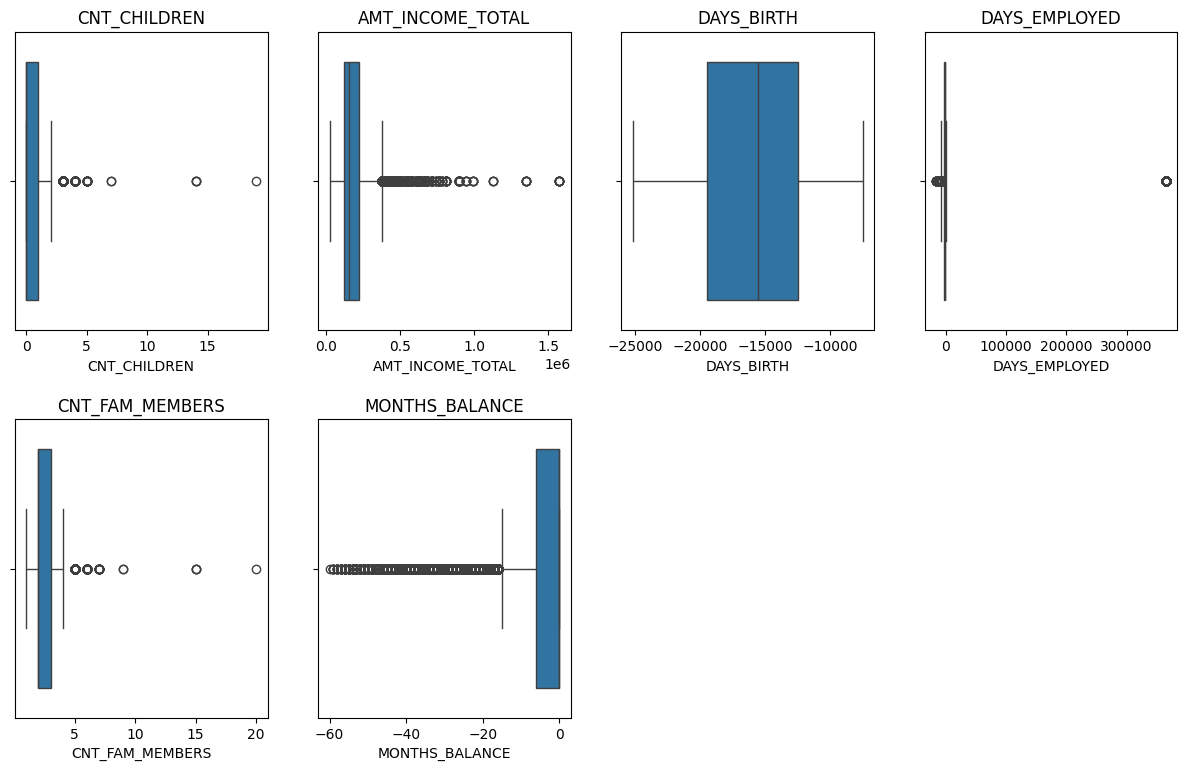

In [69]:
# numeric column 별 분포 확인
plt.figure(figsize=(15,7))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.3, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(2,4,x)
    x = x+1
    sns.boxplot(x=column_name, data=df)
    plt.title(column_name)
plt.show()

In [70]:
for column_name in list_numeric_columns:
  print(column_name, "skew : ", skew(df[column_name]), "kur : ", kurtosis(df[column_name]) )


CNT_CHILDREN skew :  2.5692764853112635 kur :  22.55917511845248
AMT_INCOME_TOTAL skew :  2.738897180151655 kur :  17.595506164509793
DAYS_BIRTH skew :  -0.18422206947290823 kur :  -1.045664746406706
DAYS_EMPLOYED skew :  1.7723702515885982 kur :  1.1430772697054437
CNT_FAM_MEMBERS skew :  1.298542476962789 kur :  8.187407769180325
MONTHS_BALANCE skew :  -2.1378871685624534 kur :  3.918957344284352


<Axes: >

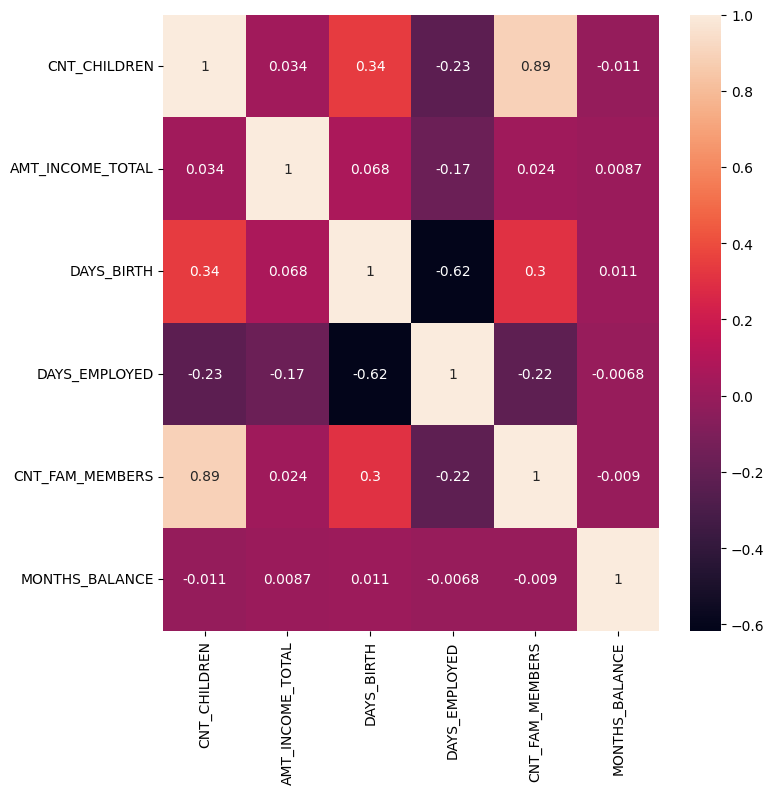

In [71]:
df_corr = df[list_numeric_columns].corr()
plt.figure(figsize=(8,8))

sns.heatmap(df_corr, annot=True)

In [72]:
index_corr_over_85 = np.where((abs(df_corr)>0.85) & (df_corr != 1))
index_corr_over_85

(array([0, 4], dtype=int64), array([4, 0], dtype=int64))

In [73]:
statistic, pvalue = stats.pearsonr(df.loc[:,"CNT_FAM_MEMBERS"], df.loc[:,"CNT_CHILDREN"])
print(statistic)
print(pvalue)

0.8891141560150977
0.0


In [74]:
def caculate_vif(df_target):
  vif = pd.DataFrame()
  vif["VIF_Factor"] = [variance_inflation_factor(df_target.values, i) for i in range(df_target.shape[1])]
  vif["Feature"] = df_target.columns
  return vif

df_vif = df[list_numeric_columns].copy()

In [75]:
caculate_vif(df[list_numeric_columns])

,VIF_Factor,Feature
0,5.501891,CNT_CHILDREN
1,4.177863,AMT_INCOME_TOTAL
2,13.927450,DAYS_BIRTH
3,1.814530,DAYS_EMPLOYED
4,20.422667,CNT_FAM_MEMBERS
5,1.259641,MONTHS_BALANCE


In [76]:
caculate_vif(df[list_numeric_columns].drop("CNT_FAM_MEMBERS", axis=1))

,VIF_Factor,Feature
0,1.317477,CNT_CHILDREN
1,4.030542,AMT_INCOME_TOTAL
2,5.406126,DAYS_BIRTH
3,1.665757,DAYS_EMPLOYED
4,1.256456,MONTHS_BALANCE


In [77]:
list_numeric_feature_by_vif = list_numeric_columns.copy()
list_numeric_feature_by_vif.remove("CNT_FAM_MEMBERS")

In [78]:
list_numeric_feature_by_vif

['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'MONTHS_BALANCE']

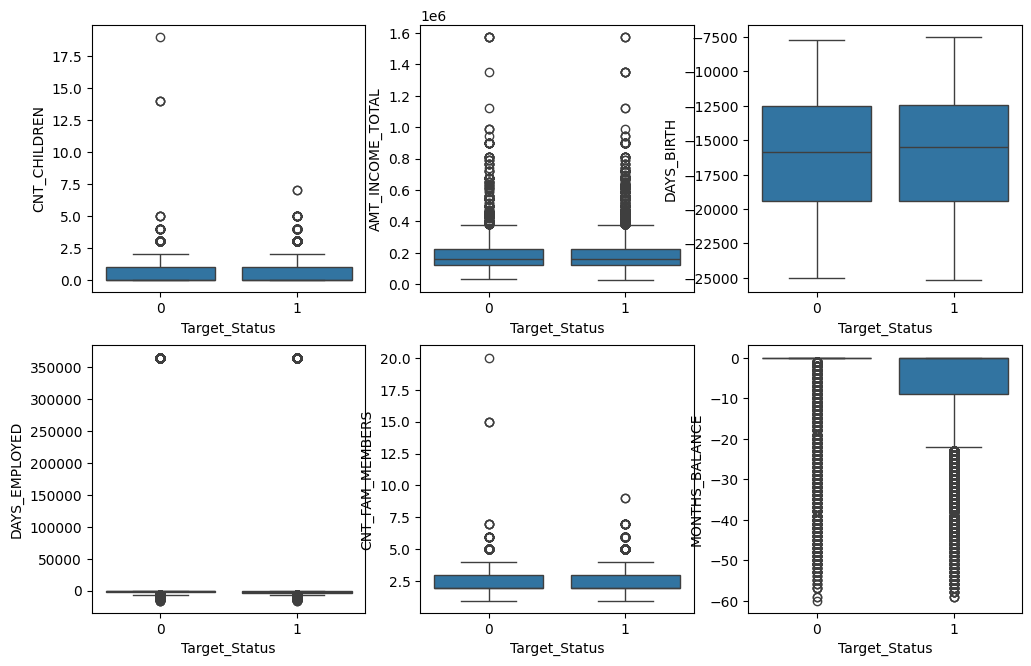

In [80]:
plt.figure(figsize=(12,6))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.2, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(2,3,x)
    x = x + 1
    sns.boxplot(data=df,x=target_column,y=column_name)
plt.show()

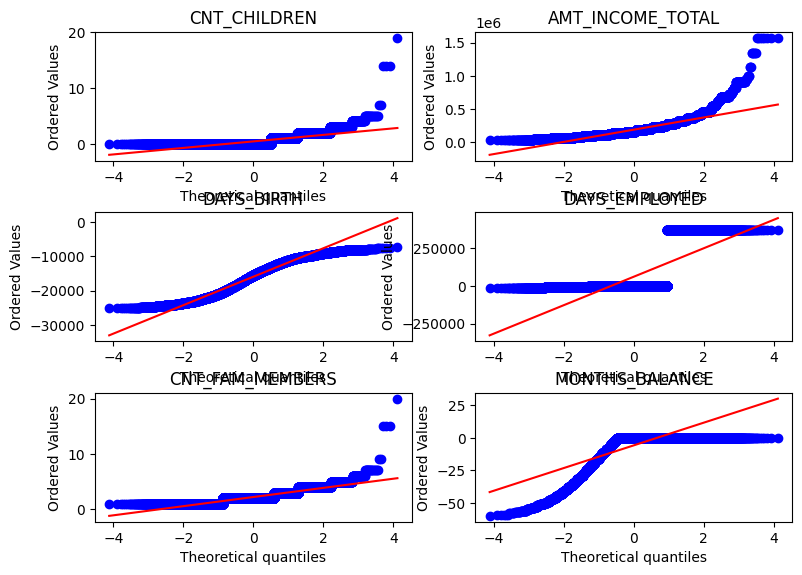

In [82]:
plt.figure(figsize=(9,5))
x = 1
plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.4, wspace=0.2)
for column_name in list_numeric_columns:
    plt.subplot(3,2,x)
    x = x+1
    stats.probplot(df[column_name], dist=stats.norm, plot=plt)
    plt.title(column_name)
plt.show()

In [83]:
list_column_normality = []
for column_name in list_numeric_columns:
  statistic, pvalue = stats.shapiro(df[column_name])
  if pvalue >= 0.05:
    list_column_normality.append(column_name)
  print(column_name, ", statistic : ", statistic, ", pvalue : ", pvalue)

print("Meet normality columns : ",len(list_column_normality))

CNT_CHILDREN , statistic :  0.6152937705806769 , pvalue :  2.2142495006866357e-125
AMT_INCOME_TOTAL , statistic :  0.8168496452628089 , pvalue :  4.158438860652268e-105
DAYS_BIRTH , statistic :  0.966297111706394 , pvalue :  1.1692021521154388e-65
DAYS_EMPLOYED , statistic :  0.46610934407707916 , pvalue :  6.535805462011858e-135
CNT_FAM_MEMBERS , statistic :  0.8236549801777469 , pvalue :  4.0234495421358244e-104
MONTHS_BALANCE , statistic :  0.591912578199909 , pvalue :  4.524659155950623e-127
Meet normality columns :  0


scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 36457.


In [84]:
list_target_unique = df[target_column].unique()
list_meaningful_column_by_kruskall = []

for column_name in list_numeric_columns:
  list_by_quality_value = []
  for quality_value in list_target_unique:
      df_tmp = df[df[target_column] == quality_value][column_name].dropna()
      list_by_quality_value.append(np.array(df_tmp))
  statistic, pvalue = kruskal(*list_by_quality_value)
  if pvalue <= 0.05:
    list_meaningful_column_by_kruskall.append(column_name)
  print(column_name, ", ",statistic,", ", pvalue)
print("all numerical columns : ", len(list_numeric_columns))
print("selected columns by kruskal : ", len(list_meaningful_column_by_kruskall), list_meaningful_column_by_kruskall)

CNT_CHILDREN ,  0.9337989725891732 ,  0.33387770621591706
AMT_INCOME_TOTAL ,  0.5387857888480218 ,  0.46293637094856877
DAYS_BIRTH ,  2.1336943086384164 ,  0.1440931072120902
DAYS_EMPLOYED ,  25.523534603497747 ,  4.370195260220316e-07
CNT_FAM_MEMBERS ,  0.9386094371351926 ,  0.33263571559306976
MONTHS_BALANCE ,  945.4711171201508 ,  1.280009852962771e-207
all numerical columns :  6
selected columns by kruskal :  2 ['DAYS_EMPLOYED', 'MONTHS_BALANCE']


In [85]:
df.profile_report().to_file("data/data_eda_with_pandasprofiling.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [86]:
list_selected_numerical = list_meaningful_column_by_kruskall.copy()

In [87]:
df_fs = df[list_meaningful_column_by_chi + list_selected_numerical + [target_column]]
df_fs.head(2)

,FLAG_OWN_REALTY,NAME_EDUCATION_TYPE,FLAG_WORK_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,DAYS_EMPLOYED,MONTHS_BALANCE,Target_Status
0,Y,Higher education,1,0,NaN,-4542,0,1
1,Y,Higher education,1,0,NaN,-4542,0,1


In [88]:
df_fs.isna().sum()

FLAG_OWN_REALTY            0
NAME_EDUCATION_TYPE        0
FLAG_WORK_PHONE            0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
DAYS_EMPLOYED              0
MONTHS_BALANCE             0
Target_Status              0
dtype: int64

In [89]:
df["OCCUPATION_TYPE"]

0                   NaN
1                   NaN
2        Security staff
3           Sales staff
4           Sales staff
              ...      
36452          Managers
36453    Medicine staff
36454    Medicine staff
36455       Sales staff
36456          Laborers
Name: OCCUPATION_TYPE, Length: 36457, dtype: object

In [90]:
imputer = CategoricalImputer()
data = np.array(df_fs['OCCUPATION_TYPE'], dtype=object)
data_fillna = imputer.fit_transform(data)

In [91]:
df_fs["OCCUPATION_TYPE"] = data_fillna


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [92]:
df_fs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   FLAG_OWN_REALTY      36457 non-null  object
 1   NAME_EDUCATION_TYPE  36457 non-null  object
 2   FLAG_WORK_PHONE      36457 non-null  object
 3   FLAG_EMAIL           36457 non-null  object
 4   OCCUPATION_TYPE      36457 non-null  object
 5   DAYS_EMPLOYED        36457 non-null  int64 
 6   MONTHS_BALANCE       36457 non-null  int64 
 7   Target_Status        36457 non-null  object
dtypes: int64(2), object(6)
memory usage: 2.2+ MB


In [93]:
df_fs.isna().sum()

FLAG_OWN_REALTY        0
NAME_EDUCATION_TYPE    0
FLAG_WORK_PHONE        0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
DAYS_EMPLOYED          0
MONTHS_BALANCE         0
Target_Status          0
dtype: int64

In [94]:
Y = df_fs[target_column]
X = df_fs.drop([target_column], axis=1)

In [95]:
Y

0        1
1        1
2        1
3        0
4        1
        ..
36452    0
36453    1
36454    1
36455    0
36456    0
Name: Target_Status, Length: 36457, dtype: object

In [112]:
le = LabelEncoder()
le.fit(Y)
Y_encoded = le.transform(Y)

In [113]:
Y_encoded


array([1, 1, 1, ..., 1, 0, 0])

In [114]:
type(Y_encoded[0])

numpy.int32

In [115]:
list_categorical_columns = list(df_fs.select_dtypes(include=['object']).columns)
list_numeric_columns = list(df_fs.select_dtypes(include=['float64','int64']).columns)
print(len(list_categorical_columns))
print(len(list_numeric_columns))

6
2


In [116]:
# minmaxscaling
scaler_minmax = MinMaxScaler()
X.loc[:, list_selected_numerical] = scaler_minmax.fit_transform(X[list_selected_numerical])
X.head(1)

,FLAG_OWN_REALTY,NAME_EDUCATION_TYPE,FLAG_WORK_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,DAYS_EMPLOYED,MONTHS_BALANCE
0,Y,Higher education,1,0,Laborers,0.029324,1.0


In [117]:
X_base = pd.get_dummies(X)
X_base.head(1)

,DAYS_EMPLOYED,MONTHS_BALANCE,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,FLAG_WORK_PHONE_0,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,0.029324,1.0,False,True,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [118]:
X_train, X_validation, y_train, y_validation = train_test_split(X_base, Y_encoded, test_size=0.2, stratify=Y_encoded)

In [128]:
random_state = 42
sm = SMOTE(random_state=random_state)
X_sm_sampling, y_sm_sampling = sm.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'After sampling for target label')

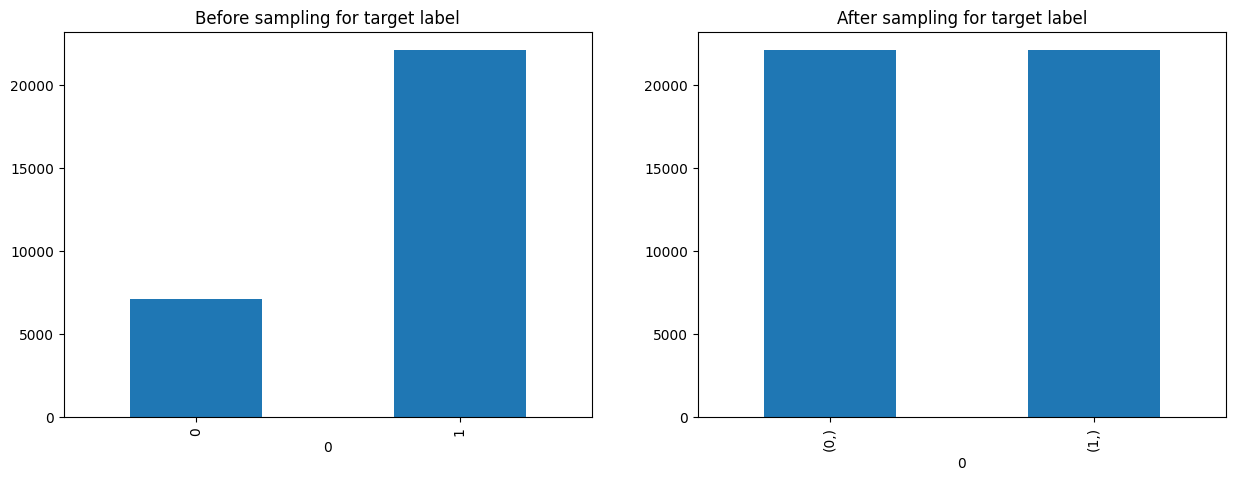

In [158]:
fig = plt.figure(figsize=(15,5))
fig.add_subplot(121)
pd.DataFrame(y_train)[0].value_counts().sort_index().plot(kind='bar')
plt.title("Before sampling for target label")

fig.add_subplot(122)
pd.DataFrame(y_sm_sampling).value_counts().sort_index().plot(kind='bar')
plt.title("After sampling for target label")

In [159]:
svm_sm = SVMSMOTE(random_state=random_state)
X_svm_sampling, y_svm_sampling = svm_sm.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'After sampling for target label')

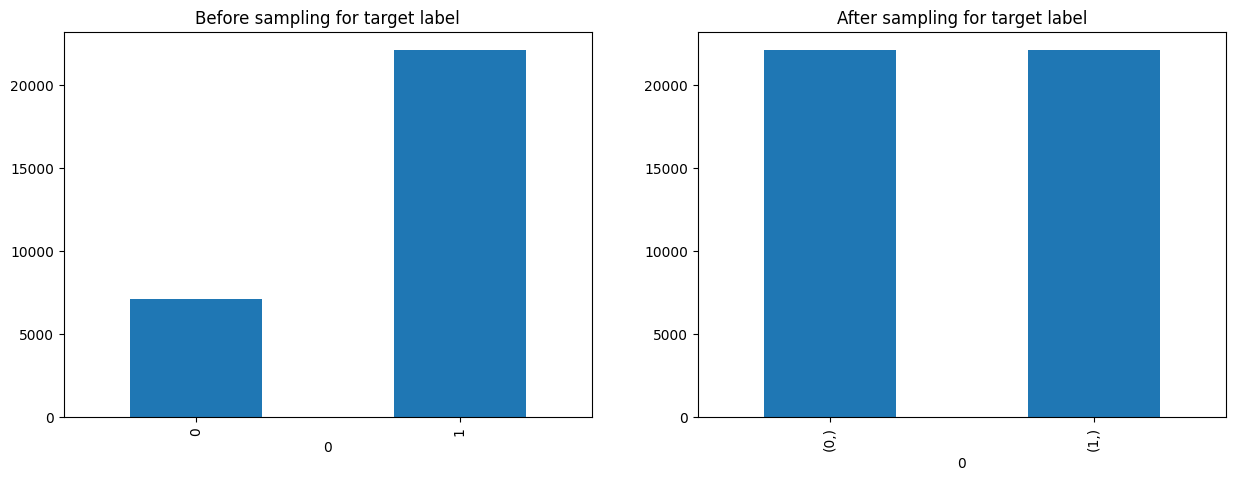

In [160]:
fig = plt.figure(figsize=(15,5))
fig.add_subplot(121)
pd.DataFrame(y_train)[0].value_counts().sort_index().plot(kind='bar')
plt.title("Before sampling for target label")

fig.add_subplot(122)
pd.DataFrame(y_sm_sampling).value_counts().sort_index().plot(kind='bar')
plt.title("After sampling for target label")

In [161]:
combined_sm = SMOTEENN(random_state=random_state)
X_csm_sampling, y_csm_sampling = combined_sm.fit_resample(X_train, y_train)

Text(0.5, 1.0, 'After sampling for target label')

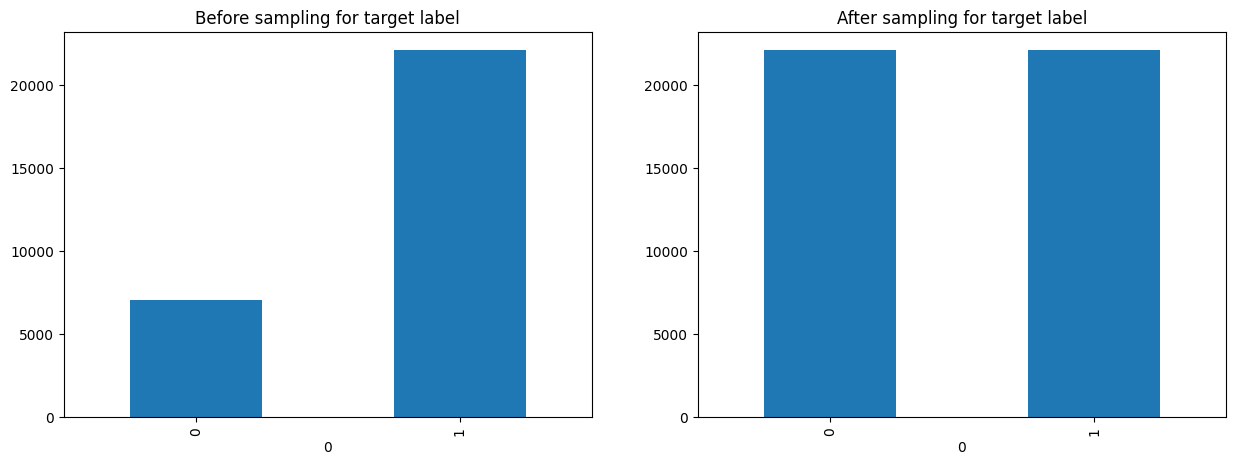

In [163]:
fig = plt.figure(figsize=(15,5))
fig.add_subplot(121)
pd.DataFrame(y_train)[0].value_counts().sort_index().plot(kind='bar')
plt.title("Before sampling for target label")

fig.add_subplot(122)
pd.DataFrame(y_sm_sampling)[0].value_counts().sort_index().plot(kind='bar')
plt.title("After sampling for target label")

In [165]:
list_model_type = []
list_model_best_params = []
list_model_f1_score = []
cv = 3
n_iter_randomsearch = 40

In [166]:
skf = StratifiedKFold(n_splits=3)
skf.get_n_splits(X_train, y_train)

3

In [167]:
list_fold_result = []
for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
  X_train_cv, X_test_cv = X_train.iloc[train_index, :], X_train.iloc[test_index, :]
  y_train_cv, y_test_cv = y_train[train_index], y_train[test_index]
  rf_clf = MLPClassifier(hidden_layer_sizes=10)
  rf_clf.fit(X_train_cv, y_train_cv)
  y_prd_test = rf_clf.predict(X_test_cv)
  y_prd_proba_test = rf_clf.predict_proba(X_test_cv)[:,-1]
  prf_score_test = precision_recall_fscore_support(y_test_cv, y_prd_test, average="macro")
  score_test = roc_auc_score(y_test_cv, y_prd_proba_test)
  print(i, " precision, recall, f1score : ", prf_score_test)
  print(i, " roc_auc_score : ", score_test)

  y_prd_validation = rf_clf.predict(X_validation)
  y_prd_proba_validation = rf_clf.predict_proba(X_validation)[:,-1]
  prf_score_validation = precision_recall_fscore_support(y_validation, y_prd_validation, average="macro")
  score_validation = roc_auc_score(y_validation, y_prd_proba_validation)
  print("validation : precision, recall, f1score : ",prf_score_validation)
  print("validation : roc_auc_score : ",score_validation)
  list_fold_result.append(prf_score_validation[2])

f1score_final = np.mean(list_fold_result)
print("average roc auc score : ",f1score_final)
list_model_type.append("Base model without sampling")
list_model_best_params.append({})
list_model_f1_score.append(f1score_final)

0  precision, recall, f1score :  (0.44118328868740986, 0.49947382686115604, 0.43145613583861336, None)
0  roc_auc_score :  0.5888151340160219
validation : precision, recall, f1score :  (0.49414543417840573, 0.49994327508756525, 0.4323647562424286, None)
validation : roc_auc_score :  0.5991574507455741
1  precision, recall, f1score :  (0.6289923758499897, 0.5011539632491047, 0.43433605410367737, None)
1  roc_auc_score :  0.5796543986063958
validation : precision, recall, f1score :  (0.517703846271347, 0.5002373435866855, 0.4334137105339283, None)
validation : roc_auc_score :  0.5882002762114148
2  precision, recall, f1score :  (0.8789359950607121, 0.5006366723259762, 0.4324020888266218, None)
2  roc_auc_score :  0.5821538110436066
validation : precision, recall, f1score :  (0.5788253053382737, 0.5002940684991203, 0.43208580225071846, None)
validation : roc_auc_score :  0.58183316076946
average roc auc score :  0.4326214230090251


<Axes: >

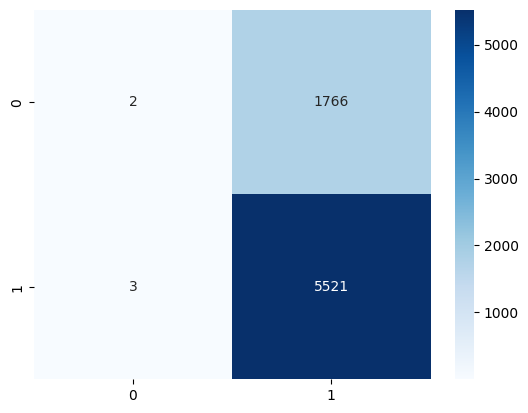

In [168]:
cm = pd.DataFrame(confusion_matrix(y_validation,y_prd_validation))
sns.heatmap(cm, cmap=plt.cm.Blues, annot=True, fmt='d')

In [169]:
def plot_roc_auc(y_true, y_prd_proba):
  fpr, tpr, _ = roc_curve(y_true,  y_prd_proba)
  auc = roc_auc_score(y_true, y_prd_proba)
  plt.figure(figsize=(7,7))
  plt.plot(fpr,tpr,label="auc="+str(auc))
  plt.legend(loc=4)
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.show()

In [170]:
def model_learning_with_randomsearch(model, hyper_parameter, X, Y, metric="roc_auc"):
  random_cv_opt = RandomizedSearchCV(estimator=model, param_distributions=hyper_parameter, n_iter=n_iter_randomsearch, cv = cv, random_state=random_state, scoring=metric, verbose=1)
  random_cv_opt.fit(X, Y)
  y_prd = random_cv_opt.predict(X_validation)
  prf_score = precision_recall_fscore_support(y_validation, y_prd, average="macro")
  y_prd_proba = random_cv_opt.predict_proba(X_validation)[:,-1]
  score = roc_auc_score(y_validation, y_prd_proba)
  print('validation -> best model hyper-parameter : ', random_cv_opt.best_params_)
  print("validation -> precision, recall, f1score : ", prf_score)
  print("validation -> roc_auc_score : ", score)

  cm = pd.DataFrame(confusion_matrix(y_validation,y_prd))
  sns.heatmap(cm, cmap=plt.cm.Blues, annot=True, fmt='d')

  return random_cv_opt.best_params_, prf_score, prf_score[2]

The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.


Fitting 3 folds for each of 32 candidates, totalling 96 fits
validation -> best model hyper-parameter :  {'warm_start': False, 'solver': 'adam', 'power_t': 0.5, 'max_iter': 10000, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': 15, 'early_stopping': True, 'alpha': 0.0001, 'activation': 'relu'}
validation -> precision, recall, f1score :  (0.3787712561711465, 0.5, 0.43102372034956304, None)
validation -> roc_auc_score :  0.5590294899918414


Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


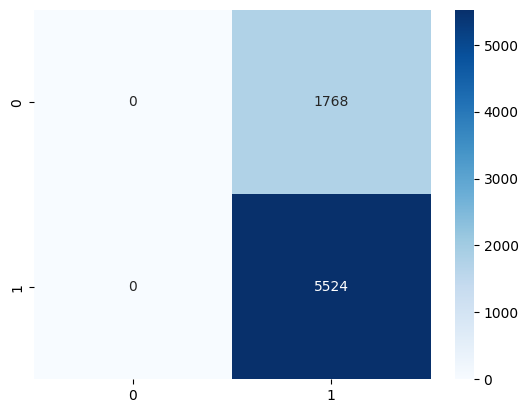

In [171]:
hyper_params_mlp = {
    'hidden_layer_sizes': [10, 15, 20, 25],
    'activation': ['tanh', 'relu'],
    'solver': ["sgd", "adam"],
    'learning_rate': ['constant'],
    'learning_rate_init': [0.001, 0.01],
    'power_t': [0.5],
    'alpha': [0.0001],
    'max_iter': [10000],
    'early_stopping': [True],
    'warm_start': [False]
              }

params, prf_score, score = model_learning_with_randomsearch(MLPClassifier(), hyper_params_mlp, X_base, Y_encoded)
list_model_type.append("model optimization with base feature")
list_model_best_params.append(params)
list_model_f1_score.append(score)

The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.


Fitting 3 folds for each of 32 candidates, totalling 96 fits
validation -> best model hyper-parameter :  {'warm_start': False, 'solver': 'adam', 'power_t': 0.5, 'max_iter': 10000, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': 25, 'early_stopping': True, 'alpha': 0.0001, 'activation': 'relu'}
validation -> precision, recall, f1score :  (0.5575269445994896, 0.5756964262895601, 0.4946561243064689, None)
validation -> roc_auc_score :  0.5919637796075373


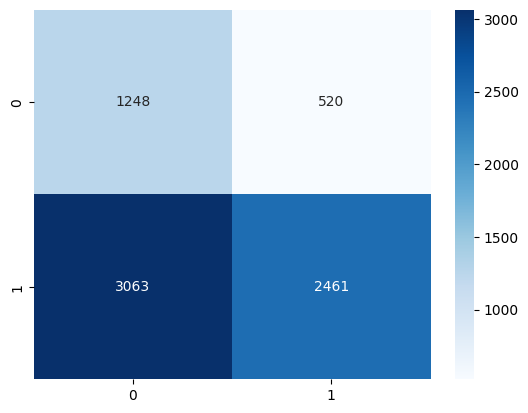

In [172]:
params, prf_score, score = model_learning_with_randomsearch(MLPClassifier(), hyper_params_mlp, X_sm_sampling, y_sm_sampling)
list_model_type.append("model optimization with smote oversampling")
list_model_best_params.append(params)
list_model_f1_score.append(score)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.


validation -> best model hyper-parameter :  {'warm_start': False, 'solver': 'adam', 'power_t': 0.5, 'max_iter': 10000, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': 25, 'early_stopping': True, 'alpha': 0.0001, 'activation': 'relu'}
validation -> precision, recall, f1score :  (0.5485981069365684, 0.5661451387773959, 0.5155864325738799, None)
validation -> roc_auc_score :  0.5929757151844195


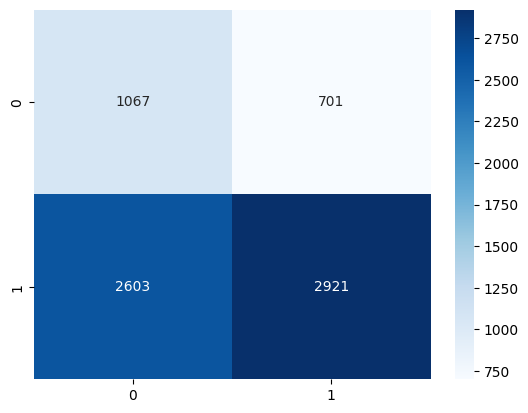

In [173]:
params, prf_score, score = model_learning_with_randomsearch(MLPClassifier(), hyper_params_mlp, X_svm_sampling, y_svm_sampling)
list_model_type.append("model optimization with svm smote oversampling")
list_model_best_params.append(params)
list_model_f1_score.append(score)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.


validation -> best model hyper-parameter :  {'warm_start': False, 'solver': 'adam', 'power_t': 0.5, 'max_iter': 10000, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': 20, 'early_stopping': True, 'alpha': 0.0001, 'activation': 'relu'}
validation -> precision, recall, f1score :  (0.5382521490880656, 0.5493676708136606, 0.5300923211169284, None)
validation -> roc_auc_score :  0.5585701615492742


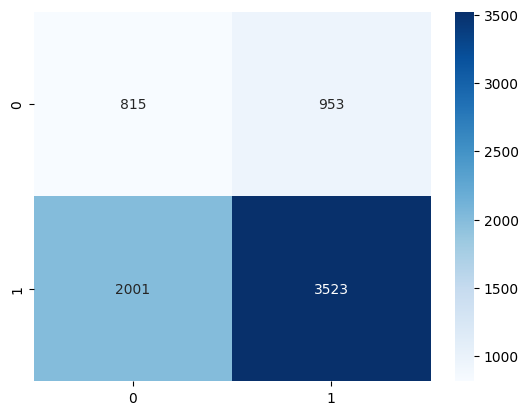

In [174]:
params, prf_score, score = model_learning_with_randomsearch(MLPClassifier(), hyper_params_mlp, X_csm_sampling, y_csm_sampling)
list_model_type.append("model optimization with smoteenn combined sampling")
list_model_best_params.append(params)
list_model_f1_score.append(score)

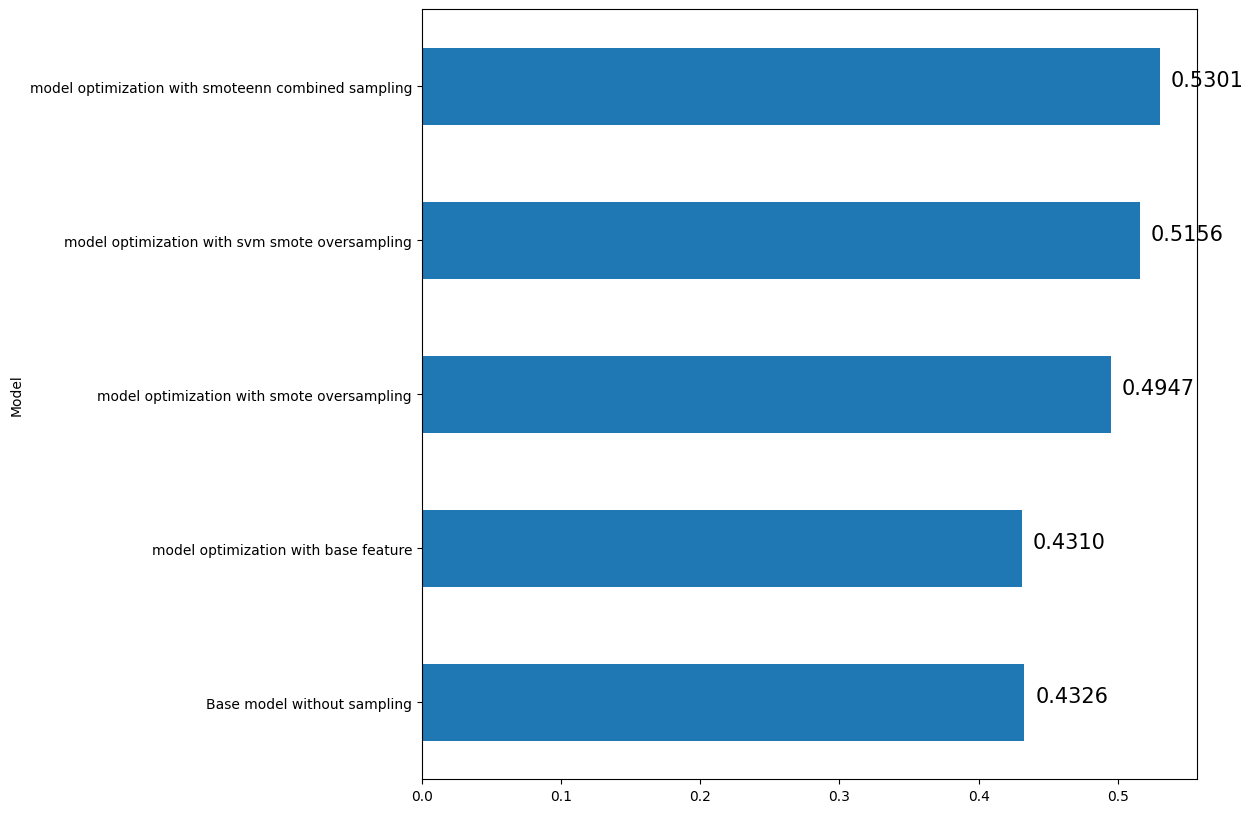

In [175]:
df_metric = pd.DataFrame({'Model':list_model_type, 'f1score_macro':list_model_f1_score})
ax = df_metric.plot.barh(x='Model', y='f1score_macro', rot=0, figsize=(10,10), legend=False)
for bar in ax.patches:
    ax.annotate(format(bar.get_width(), '.4f'),
                   (bar.get_width(), bar.get_y() + bar.get_height() / 2), 
                   size=15, xytext=(8, 0),
                   textcoords='offset points')

In [176]:
mlp_final = MLPClassifier(**{'warm_start': False, 'solver': 'adam', 'power_t': 0.5, 'max_iter': 10000, 'learning_rate_init': 0.01, 'learning_rate': 'constant', 'hidden_layer_sizes': 25, 'early_stopping': True, 'alpha': 0.0001, 'activation': 'relu'})
mlp_final.fit(X_csm_sampling, y_csm_sampling)

MLPClassifier(early_stopping=True, hidden_layer_sizes=25,
              learning_rate_init=0.01, max_iter=10000)

In [177]:
explainer = shap.Explainer(lambda x : mlp_final.predict_log_proba(x)[:,1], X_validation)
shap_values = explainer(X_validation)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
shap.summary_plot(shap_values, X_validation)